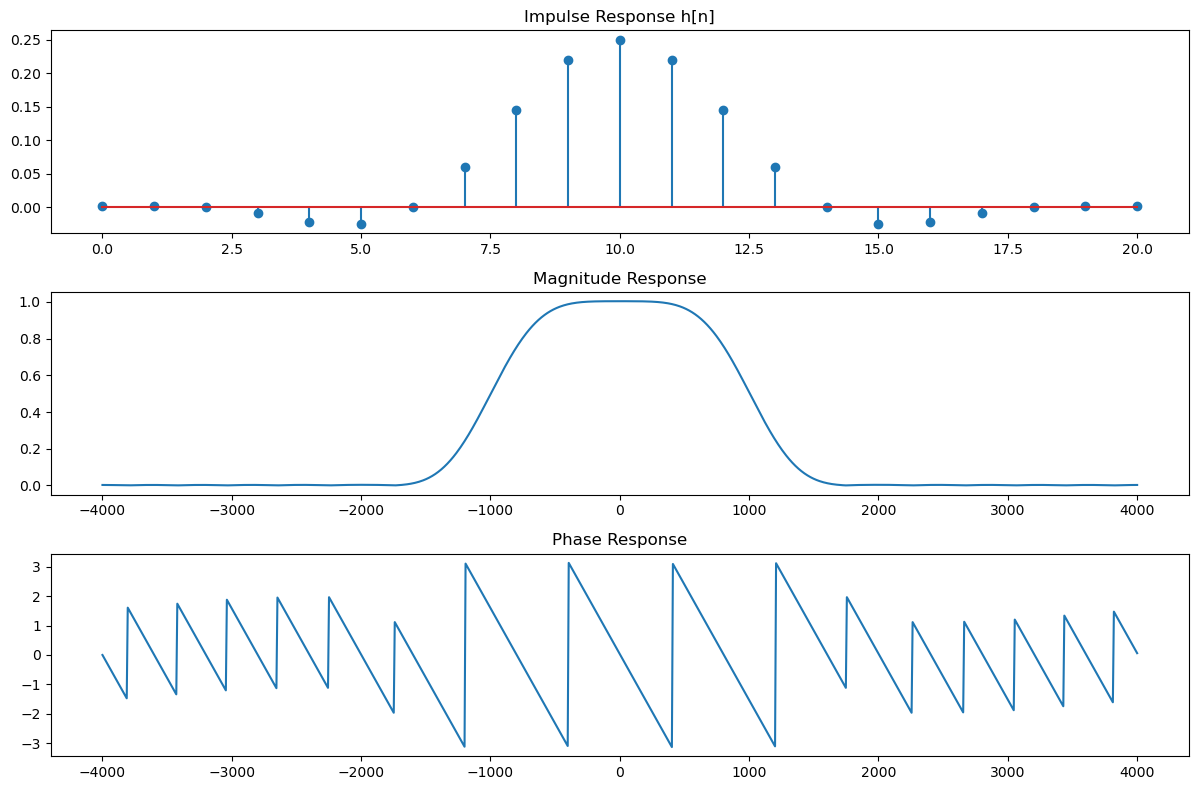

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Given specs
fs = 8000
fc = 1000
N = 21

# index
n = np.arange(N)
m = (N - 1) / 2

# Ideal impulse response
hd = (2 * fc / fs) * np.sinc((2 * fc / fs) * (n - m))

# Hamming window
w = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))

# FIR filter
h = hd * w

# -------------------------
# Frequency response
H = np.fft.fft(h, 1024)
H_shift = np.fft.fftshift(H)
freq = np.linspace(-fs/2, fs/2, 1024)

# -------------------------
# Plots
plt.figure(figsize=(12,8))

# Impulse response
plt.subplot(3,1,1)
plt.stem(n, h)
plt.title("Impulse Response h[n]")

# Magnitude response
plt.subplot(3,1,2)
plt.plot(freq, np.abs(H_shift))
plt.title("Magnitude Response")

# Phase response
plt.subplot(3,1,3)
plt.plot(freq, np.angle(H_shift))
plt.title("Phase Response")

plt.tight_layout()
plt.show()

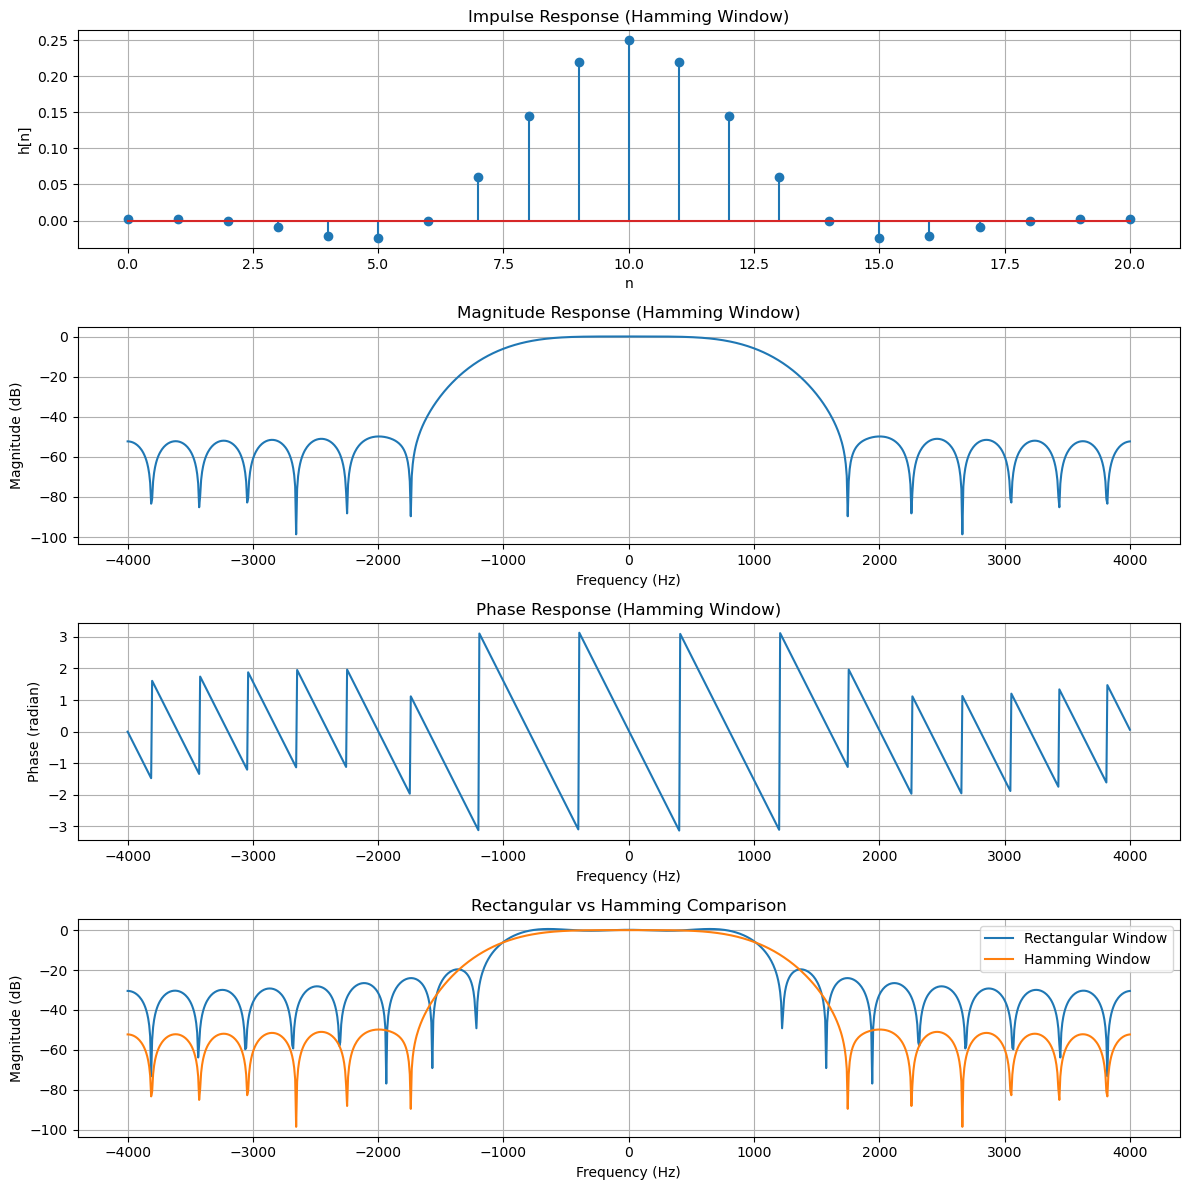

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Given Specifications
# =====================================
fs = 8000
fc = 1000
N = 21

# =====================================
# Step 1: Ideal Impulse Response
# =====================================
n = np.arange(N)
m = (N - 1) / 2

hd = (2 * fc / fs) * np.sinc((2 * fc / fs) * (n - m))

# =====================================
# Step 2: Windows
# =====================================

# Hamming Window
w_hamm = 0.54 - 0.46 * np.cos((2 * np.pi * n) / (N - 1))

# Rectangular Window
w_rect = np.ones(N)

# =====================================
# Step 3: FIR Filters
# =====================================
h_hamm = hd * w_hamm
h_rect = hd * w_rect

# =====================================
# Step 4: Frequency Response
# =====================================
H_hamm = np.fft.fft(h_hamm, 1024)
H_rect = np.fft.fft(h_rect, 1024)

H_hamm_shift = np.fft.fftshift(H_hamm)
H_rect_shift = np.fft.fftshift(H_rect)

freq = np.linspace(-fs/2, fs/2, 1024)

mag_hamm = 20 * np.log10(np.abs(H_hamm_shift) + 1e-10)
mag_rect = 20 * np.log10(np.abs(H_rect_shift) + 1e-10)
phase_hamm = np.angle(H_hamm_shift)

# =====================================
# Step 5: Plotting
# =====================================
plt.figure(figsize=(12,12))

# -------------------------------------
# Impulse Response (Hamming)
# -------------------------------------
plt.subplot(4,1,1)
plt.stem(n, h_hamm)
plt.title("Impulse Response (Hamming Window)")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid(True)

# -------------------------------------
# Magnitude Response (Hamming)
# -------------------------------------
plt.subplot(4,1,2)
plt.plot(freq, mag_hamm)
plt.title("Magnitude Response (Hamming Window)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)

# -------------------------------------
# Phase Response (Hamming)
# -------------------------------------
plt.subplot(4,1,3)
plt.plot(freq, phase_hamm)
plt.title("Phase Response (Hamming Window)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radian)")
plt.grid(True)

# -------------------------------------
# Comparison Graph
# -------------------------------------
plt.subplot(4,1,4)
plt.plot(freq, mag_rect, label="Rectangular Window")
plt.plot(freq, mag_hamm, label="Hamming Window")
plt.title("Rectangular vs Hamming Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()